In [535]:
import numpy as np
import pandas as pd

In [536]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [537]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [538]:
df.shape

(5572, 5)

### Flow of the Process

1. Data cleaning
2. EDA
3. text preprocessing
4. model building
5. evaluation
6. imporvement
7. website
8. deploy

In [539]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [540]:
df['Unnamed: 4'].value_counts()

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64

# Data Cleaning

#### Checking if any missing value exist

In [541]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

#### Checking for duplicated values and dropping if exist 

In [542]:
df.duplicated().sum()

np.int64(403)

In [543]:
df = df.drop_duplicates(keep='first')

In [544]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [545]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5169 non-null   object
 1   v2          5169 non-null   object
 2   Unnamed: 2  43 non-null     object
 3   Unnamed: 3  10 non-null     object
 4   Unnamed: 4  5 non-null      object
dtypes: object(5)
memory usage: 242.3+ KB


#### Dropping last 3 columns as they are not providing such valuable information

In [546]:
df = df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'])

In [547]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Renaming the columns to Useful names

In [548]:
df = df.rename(columns={'v1':'target','v2':'message'})

In [549]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### LabelEncoding the target column (spam is encoded as 1)

In [550]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [551]:
df['target'] = encoder.fit_transform(df['target'])

In [552]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# EDA

In [553]:
import matplotlib.pyplot as plt
import seaborn as sns

In [554]:
df.sample(3)

,target,message
332,1,Call Germany for only 1 pence per minute! Call...
4246,1,Text PASS to 69669 to collect your polyphonic ...
930,0,I'm really sorry i won't b able 2 do this frid...


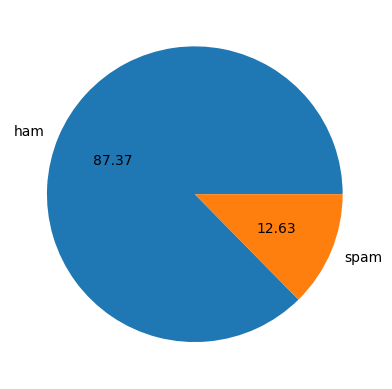

In [555]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [556]:
!pip install nltk

#### Feature engineering for columns 'num_of_chars' & 'num_of_words'

In [557]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')    


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\namde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\namde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [558]:
df['num_of_chars'] = df['message'].apply(len)

In [559]:
df['message'].apply(lambda x: x.split())

0       [Go, until, jurong, point,, crazy.., Available...
1                    [Ok, lar..., Joking, wif, u, oni...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor..., U, c, already...
4       [Nah, I, don't, think, he, goes, to, usf,, he,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568       [Will, Ì_, b, going, to, esplanade, fr, home?]
5569    [Pity,, *, was, in, mood, for, that., So...any...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                    [Rofl., Its, true, to, its, name]
Name: message, Length: 5169, dtype: object

In [560]:
df['num_of_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [561]:
df['num_of_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [562]:
df.head()

,target,message,num_of_chars,num_of_words,num_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [563]:
# Statistics for ham messages
df[df['target'] == 0][['num_of_chars','num_of_words','num_of_sentences']].describe()

,num_of_chars,num_of_words,num_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [564]:
# Statistics for spam messages
df[df['target'] == 1][['num_of_chars','num_of_words','num_of_sentences']].describe()

,num_of_chars,num_of_words,num_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: title={'center': "Comparing 'Number of characters' with Ham and Spam Messages"}, xlabel='num_of_chars', ylabel='Count'>

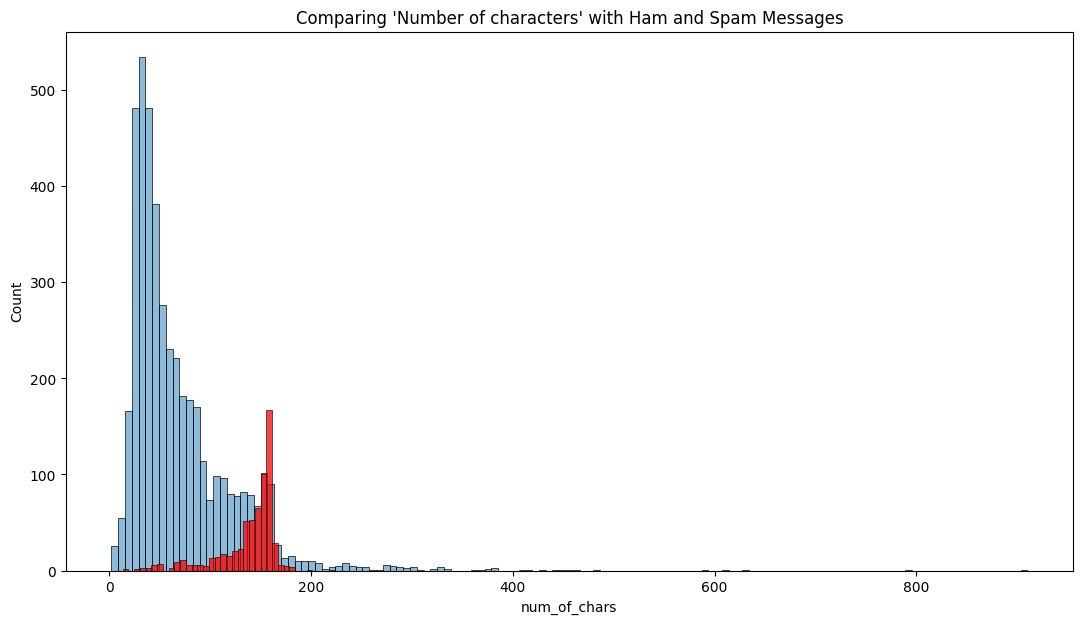

In [565]:
plt.figure(figsize=(13,7))
plt.title("Comparing 'Number of characters' with Ham and Spam Messages")
sns.histplot(df[df['target'] == 0]['num_of_chars'],alpha=0.5)
sns.histplot(df[df['target'] == 1]['num_of_chars'],color='red')

In [566]:
# As we can see that the SPAM messages are used to be longer than HAM messages

In [567]:
df.head()

,target,message,num_of_chars,num_of_words,num_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [568]:
df[['target','num_of_chars','num_of_words','num_of_sentences']].corr()

,target,num_of_chars,num_of_words,num_of_sentences
target,1.000000,0.384717,0.262912,0.263939
num_of_chars,0.384717,1.000000,0.965760,0.624139
num_of_words,0.262912,0.965760,1.000000,0.679971
num_of_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

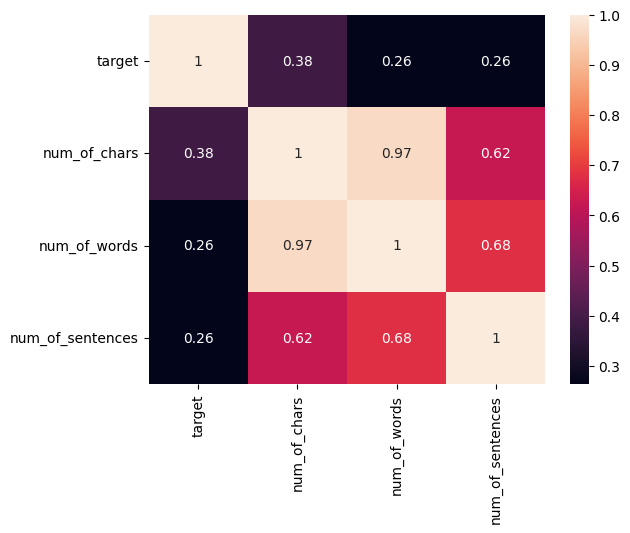

In [569]:
sns.heatmap(df[['target','num_of_chars','num_of_words','num_of_sentences']].corr(), annot=True)

In [570]:
# Data has multicolinearity as the features having kinda strong relation between each other,
# so need to remove some feature and considering only one 
# The feature 'num_of_char' makes the strongest relation to the Target column so considering that feature among these 3 features 

# Data Preprocessing
* converts to lower case
* tokenize the words
* removing special characters
* removing stop and punctuations
* stemming

In [571]:
# Stop words are the words which contributes to sentence formation but it does have any meaning 
# e.g. is, of, the, you etc. 
# 
# Stemming -> Convert words to their root words
# e.g. dancing - dance, working - work  

In [572]:
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def process(text):
    text = text.lower()  # lower case

    text = nltk.word_tokenize(text)      # tokenize

    y = []                  # remove special characters
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()                # removes stop words and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return ' '.join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\namde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [573]:
process('What you upto? im going for dancing')

'upto im go danc'

In [574]:
# Actual message
df['message'][4]

"Nah I don't think he goes to usf, he lives around here though"

In [575]:
# Transformed message
process(df['message'][4])

'nah think goe usf live around though'

In [576]:
df['transformed_message'] = df['message'].apply(process)
df.head()

,target,message,num_of_chars,num_of_words,num_of_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


#### Making a wordcloud for Spam messages

In [577]:
from wordcloud import WordCloud
wc = WordCloud(width=600, height=600, min_font_size=10, background_color='white')

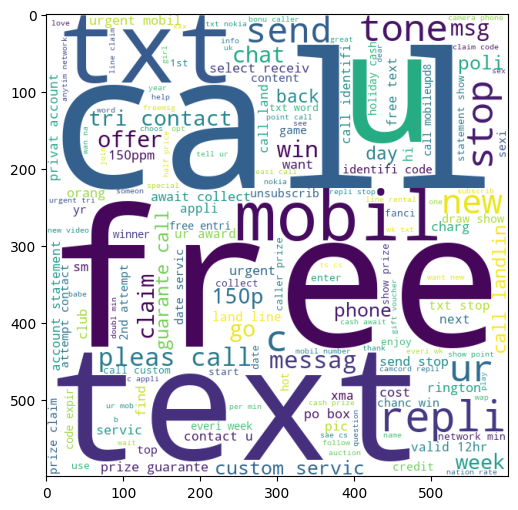

In [578]:
spam = wc.generate(df[df['target'] == 1]['transformed_message'].str.cat(sep=' '))
plt.figure(figsize=(6,6))
plt.imshow(spam)

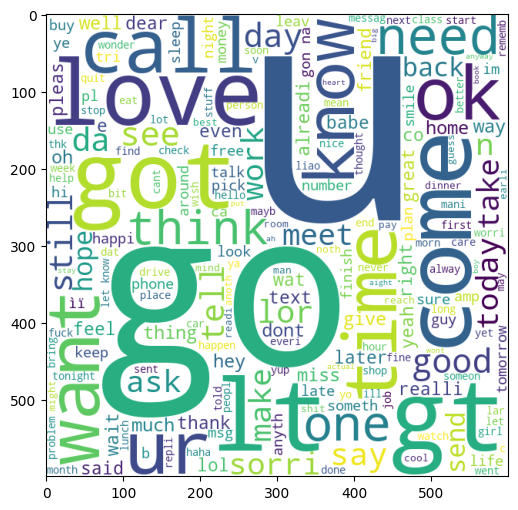

In [579]:
spam = wc.generate(df[df['target'] == 0]['transformed_message'].str.cat(sep=' '))
plt.figure(figsize=(6,6))
plt.imshow(spam)
plt.show()

#### Retrieving top 30 words from Spam messages

In [580]:
lst = []
for msg in df[df['target'] == 1]['transformed_message'].to_list():
    for words in msg.split():
        lst.append(words)

len(lst)

9939

In [581]:
from collections import Counter     # Counts the word and save it to a dictionary
Counter(lst)

Counter({'call': 320,
         'free': 191,
         '2': 155,
         'txt': 141,
         'text': 122,
         'u': 119,
         'ur': 119,
         'mobil': 114,
         'stop': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'prize': 82,
         'get': 74,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 60,
         'urgent': 57,
         'nokia': 57,
         'contact': 56,
         'award': 55,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 48,
         'c': 45,
         'collect': 45,
         'min': 45,
         'custom': 42,
         'messag': 42,
         'guarante': 42,
         'per': 41,
         'chat': 38,
         'tri': 37,
         'msg': 35,
         'draw': 35,
         'number': 35,
         'cs': 35,
         'show': 33,
         'today': 33,
         'offer': 33,
         'line': 33,
         'go': 32,
         'receiv': 31,
         'want': 3

C:\Users\namde\AppData\Local\Temp\ipykernel_19972\3025966343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word', y='count', data=top30, palette='rainbow')


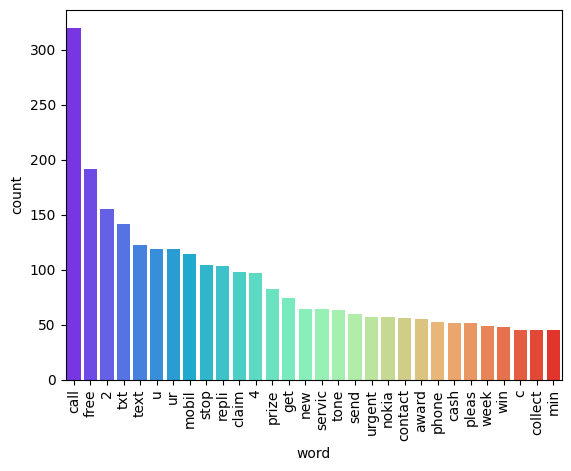

In [582]:
top30 = pd.DataFrame(Counter(lst).most_common(30), columns=['word','count'])
sns.barplot(x='word', y='count', data=top30, palette='rainbow')
plt.xticks(rotation=90)
plt.show()

In [583]:
df.head()

,target,message,num_of_chars,num_of_words,num_of_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


#### Top 30 words from Ham messages

In [584]:
ham_lst = []
for msg in df[df['target'] == 0]['transformed_message'].to_list():
    for word in msg.split():
        ham_lst.append(word)

In [585]:
len(ham_lst)

35404

In [586]:
Counter(ham_lst)

Counter({'u': 883,
         'go': 404,
         'get': 349,
         'gt': 288,
         'lt': 287,
         '2': 284,
         'come': 275,
         'got': 236,
         'know': 236,
         'like': 234,
         'call': 233,
         'time': 219,
         'ok': 217,
         'love': 216,
         'good': 213,
         'want': 208,
         'ur': 197,
         'day': 190,
         'need': 170,
         'one': 165,
         'lor': 159,
         '4': 156,
         'home': 152,
         'think': 149,
         'see': 147,
         'take': 143,
         'still': 143,
         'da': 142,
         'tell': 133,
         'make': 129,
         'say': 127,
         'back': 127,
         'today': 123,
         'hope': 122,
         'ask': 121,
         'sorri': 121,
         'n': 120,
         'send': 120,
         'r': 120,
         'work': 118,
         'dont': 118,
         'meet': 112,
         'hi': 111,
         'well': 109,
         'thing': 109,
         'wat': 108,
         'k': 107,
  

C:\Users\namde\AppData\Local\Temp\ipykernel_19972\1900263698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word', y='count', data=top30, palette='rainbow')


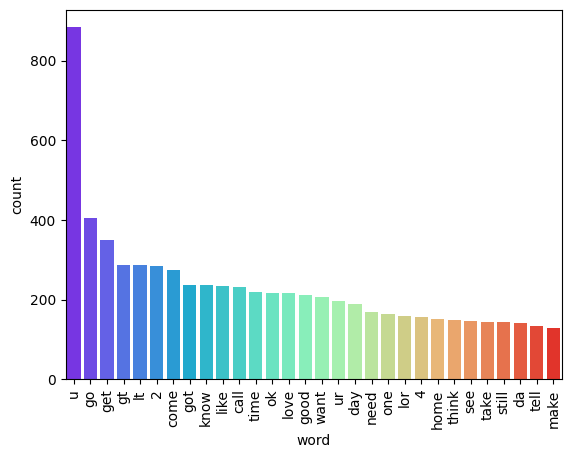

In [587]:
top30 = pd.DataFrame(Counter(ham_lst).most_common(30), columns=['word','count'])
sns.barplot(x='word', y='count', data=top30, palette='rainbow')
plt.xticks(rotation=90)
plt.show()

# Model building

As the data has 2 main columns that are Target and Transformed_message, The target feature is already numeric and need to make the Transformed_message also numeric to feed it to the model.

So the Vectorization is needed to transform it

#### Train-test-split

In [588]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer()

In [589]:
X = tf.fit_transform(df['transformed_message']).toarray()       # Converted sparse array to dense array

In [590]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 6708))

In [591]:
X.shape

(5169, 6708)

In [592]:
df.shape

(5169, 6)

In [593]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [594]:
from sklearn.model_selection import train_test_split
X_train, y_train, X_test, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#### Model

In [595]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [596]:
from sklearn.metrics import accuracy_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [597]:
lm = LogisticRegression(solver='liblinear', penalty='11')
svc = SVC(kernel='sigmoid', gamma=1.0)
nb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=42)

In [598]:
classifiers = {
'SVC':svc, 
'NB':nb ,
'DTC':dtc, 
'KNC':knc, 
'RFC':rfc, 
'ABC':abc, 
'BgC':bc ,
'ETC':etc, 
'GBC':gbc
}

In [599]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy, precision

In [600]:
accuracy_scores = []
precision_scores = []

for name, clf in classifiers.items():
    current_accuracy, current_precision = train_classifier(clf, X_train=X_train,
                                                           y_train=y_train,
                                                           X_test = X_test,
                                                           y_test = y_test)
    
    print(name)
    print('Accuracy: ', current_accuracy)
    print('Precision: ', current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

SVC
Accuracy:  0.971953578336557
Precision:  0.9393939393939394
NB
Accuracy:  0.9613152804642167
Precision:  0.9906542056074766
DTC
Accuracy:  0.9352030947775629
Precision:  0.8145161290322581
KNC
Accuracy:  0.8965183752417795
Precision:  1.0
RFC
Accuracy:  0.9700193423597679
Precision:  0.9913793103448276
ABC
Accuracy:  0.9148936170212766
Precision:  0.7878787878787878
BgC
Accuracy:  0.9622823984526112
Precision:  0.8897058823529411
ETC
Accuracy:  0.9729206963249516
Precision:  0.975609756097561
GBC
Accuracy:  0.9516441005802708
Precision:  0.9611650485436893


In [601]:
performance_df = pd.DataFrame({
    'Algorithm':classifiers.keys(),
    'Accuracy':accuracy_scores,
    'Precision':precision_scores
})

performance_df.sort_values('Precision', ascending=False)

,Algorithm,Accuracy,Precision
3,KNC,0.896518,1.000000
4,RFC,0.970019,0.991379
1,NB,0.961315,0.990654
7,ETC,0.972921,0.975610
8,GBC,0.951644,0.961165
0,SVC,0.971954,0.939394
6,BgC,0.962282,0.889706
2,DTC,0.935203,0.814516
5,ABC,0.914894,0.787879


In [611]:
import pickle
pickle.dump(tf, open('D:/TempML/vectorizer.pkl', 'wb'))
pickle.dump(rfc, open('D:/TempML/RandomForestModel.pkl', 'wb'))